# Aula 7 — Análise exploratória de dados: distribuições, frequências e variabilidade

**Fundamentos de Programação para Inteligência Artificial na Saúde**
Mestrado e Doutorado Stricto Sensu em Ciências da Saúde — Einstein

Este notebook reúne, na mesma ordem da aula, todos os comandos e exercícios apresentados.
Base utilizada: `pacientes_aula7_enriquecido.csv`, gerada no início deste notebook a partir de `pacientes_aula6_limpo.csv` com as variáveis derivadas da Aula 6.



---
## 01 · Da agregação à distribuição

**Onde a Aula 6 terminou:** uma média ou uma proporção consegue representar sozinha o comportamento dos dados?

**Análise exploratória de dados (EDA)** é a investigação sistemática da estrutura, do comportamento e da qualidade da base.
Não é confirmação de hipótese nem conclusão causal. Combina resumos numéricos, tabelas de frequência e inspeções visuais.

---
## 02 · Conhecendo a base

### O que cada linha representa

- **Linha:** uma internação de um paciente.
- **Coluna:** uma característica, medida ou variável derivada.
- **`groupby()`:** a unidade passa a ser o grupo resumido.

### Numéricas e categóricas

| Tipo | Variáveis |
|---|---|
| Numéricas | `idade` · `tempo_internacao_dias` · `internacoes_anteriores` |
| Categóricas | `servico` · `readmissao_30d` · `faixa_etaria` · `categoria_permanencia` |

`readmissao_30d` é armazenada como 0 e 1, mas representa uma categoria binária.

### Notebook e arquivo da aula: gerar a base enriquecida

A base da Aula 7 é a mesma da Aula 6, acrescida das variáveis derivadas criadas naquela aula.
As células abaixo partem de `pacientes_aula6_limpo.csv`, reconstroem essas variáveis e salvam o resultado como `pacientes_aula7_enriquecido.csv`.
Se você já tem esse arquivo, pode pular para a leitura.

In [2]:
import pandas as pd
import numpy as np

base = pd.read_csv(
    "pacientes_aula6_limpo.csv",
    parse_dates=["data_nascimento", "data_admissao", "data_alta"]
)
print(base.shape)

(60, 9)


**Variáveis derivadas da Aula 6**

In [3]:
base["tempo_internacao_horas"] = base["tempo_internacao_dias"] * 24

idade_dias = (base["data_admissao"] - base["data_nascimento"]).dt.days
base["idade_calculada"] = np.floor(idade_dias / 365.25).astype("Int64")

base["tempo_calculado"] = (base["data_alta"] - base["data_admissao"]).dt.days
base["diferenca_tempo"] = base["tempo_internacao_dias"] - base["tempo_calculado"]

base["internacao_prolongada"] = np.where(
    base["tempo_internacao_dias"] > 7, "sim", "nao"
)

condicoes = [
    base["internacoes_anteriores"] == 0,
    base["internacoes_anteriores"].between(1, 2),
    base["internacoes_anteriores"] >= 3
]
categorias = ["nenhuma", "1 a 2", "3 ou mais"]
base["historico"] = np.select(condicoes, categorias, default="nao classificado")

base["teve_internacao_previa"] = np.where(
    base["internacoes_anteriores"] > 0, "sim", "nao"
)

**Categorias usadas na Aula 7** (`faixa_etaria` e `categoria_permanencia`).
Os cortes são didáticos: em um estudo, viriam de protocolo, literatura ou desenho do estudo.

In [4]:
base["faixa_etaria"] = np.select(
    [
        base["idade"] < 40,
        base["idade"].between(40, 59),
        base["idade"].between(60, 79),
        base["idade"] >= 80
    ],
    ["menos de 40", "40 a 59", "60 a 79", "80 ou mais"],
    default="nao classificado"
)

base["categoria_permanencia"] = np.select(
    [
        base["tempo_internacao_dias"] <= 3,
        base["tempo_internacao_dias"].between(4, 7),
        base["tempo_internacao_dias"] > 7
    ],
    ["ate 3 dias", "4 a 7 dias", "mais de 7 dias"],
    default="nao classificado"
)

base[["idade", "faixa_etaria", "tempo_internacao_dias", "categoria_permanencia"]].head()

,idade,faixa_etaria,tempo_internacao_dias,categoria_permanencia
0,81,80 ou mais,12.0,mais de 7 dias
1,34,menos de 40,8.0,mais de 7 dias
2,42,40 a 59,5.0,4 a 7 dias
3,47,40 a 59,1.0,ate 3 dias
4,87,80 ou mais,5.0,4 a 7 dias


**Salvar a base enriquecida**

In [5]:
base.to_csv("pacientes_aula7_enriquecido.csv", index=False)
print("Arquivo salvo:", base.shape)

Arquivo salvo: (60, 18)


### Leitura e verificação inicial

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pacientes_aula7_enriquecido.csv")
df.head()

,id_paciente,data_nascimento,idade,data_admissao,data_alta,tempo_internacao_dias,internacoes_anteriores,servico,readmissao_30d,tempo_internacao_horas,idade_calculada,tempo_calculado,diferenca_tempo,internacao_prolongada,historico,teve_internacao_previa,faixa_etaria,categoria_permanencia
0,101,1944-08-21,81,2026-03-01,2026-03-13,12.0,0,Cardiologia,0,288.0,81,12,0.0,sim,nenhuma,nao,80 ou mais,mais de 7 dias
1,102,1992-02-15,34,2026-03-22,2026-03-30,8.0,0,Clínica Médica,0,192.0,34,8,0.0,sim,nenhuma,nao,menos de 40,mais de 7 dias
2,103,1984-01-15,42,2026-05-14,2026-05-19,5.0,0,Neurologia,1,120.0,42,5,0.0,nao,nenhuma,nao,40 a 59,4 a 7 dias
3,104,1978-09-22,47,2026-03-23,2026-03-24,1.0,1,Ortopedia,0,24.0,47,1,0.0,nao,1 a 2,sim,40 a 59,ate 3 dias
4,105,1938-10-14,87,2026-04-11,2026-04-16,5.0,2,Cardiologia,0,120.0,87,5,0.0,nao,1 a 2,sim,80 ou mais,4 a 7 dias


In [7]:
print(df.shape)
print(df.dtypes)

(60, 18)
id_paciente                 int64
data_nascimento            object
idade                       int64
data_admissao              object
data_alta                  object
tempo_internacao_dias     float64
internacoes_anteriores      int64
servico                    object
readmissao_30d              int64
tempo_internacao_horas    float64
idade_calculada             int64
tempo_calculado             int64
diferenca_tempo           float64
internacao_prolongada      object
historico                  object
teve_internacao_previa     object
faixa_etaria               object
categoria_permanencia      object
dtype: object


---
## 03 · Frequências e ausências

### Ausências também descrevem a base

In [8]:
df.isna().sum()

,0
id_paciente,0
data_nascimento,0
idade,0
data_admissao,0
data_alta,0
tempo_internacao_dias,2
internacoes_anteriores,0
servico,0
readmissao_30d,0
tempo_internacao_horas,2


In [9]:
ausencias_pct = df.isna().mean() * 100
ausencias_pct.sort_values(ascending=False)

,0
tempo_internacao_horas,3.333333
tempo_internacao_dias,3.333333
diferenca_tempo,3.333333
id_paciente,0.000000
data_nascimento,0.000000
data_admissao,0.000000
data_alta,0.000000
internacoes_anteriores,0.000000
servico,0.000000
idade,0.000000


O número de observações válidas faz parte de todo resultado.

> Uma estatística calculada sobre 100% da base e outra calculada sobre apenas 60% das observações não possuem o mesmo contexto.

### Frequência de categorias

- **Absoluta:** quantas observações há em cada categoria.
- **Relativa:** que fração do conjunto pertence a cada categoria.

In [10]:
df["servico"].value_counts()

,count
servico,
Cardiologia,15
Clínica Médica,15
Neurologia,15
Ortopedia,15


In [11]:
df["servico"].value_counts(normalize=True)

,proportion
servico,
Cardiologia,0.25
Clínica Médica,0.25
Neurologia,0.25
Ortopedia,0.25


In [12]:
df["servico"].value_counts(normalize=True).mul(100).round(1)

,proportion
servico,
Cardiologia,25.0
Clínica Médica,25.0
Neurologia,25.0
Ortopedia,25.0


In [13]:
df["servico"].value_counts(dropna=False)

,count
servico,
Cardiologia,15
Clínica Médica,15
Neurologia,15
Ortopedia,15


`dropna=False` mostra as ausências como parte da variável.

### Descrevendo o desfecho

In [14]:
df["readmissao_30d"].value_counts(dropna=False)

,count
readmissao_30d,
0,48
1,12


In [15]:
df["readmissao_30d"].value_counts(normalize=True, dropna=False).mul(100)

,proportion
readmissao_30d,
0,80.0
1,20.0


---
## 04 · Tendência central

### Primeiro resumo com `describe()`

| Linha | Significado |
|---|---|
| `count` | valores não ausentes |
| `mean` | média |
| `std` | desvio-padrão |
| `min` | menor valor |
| `25%` | primeiro quartil |
| `50%` | mediana |
| `75%` | terceiro quartil |
| `max` | maior valor |

In [16]:
df[["idade", "tempo_internacao_dias", "internacoes_anteriores"]].describe()

,idade,tempo_internacao_dias,internacoes_anteriores
count,60.000000,58.000000,60.000000
mean,60.583333,6.758621,1.516667
std,17.973890,3.525896,1.836464
min,22.000000,1.000000,0.000000
25%,45.750000,4.000000,0.000000
50%,61.500000,6.500000,1.000000
75%,77.000000,9.000000,2.000000
max,88.000000,15.000000,6.000000


`mean` e `50%` são próximos? `min` e `max` são plausíveis?

### Média: útil, mas insuficiente

In [17]:
media_idade = df["idade"].mean()
media_tempo = df["tempo_internacao_dias"].mean()
print(media_idade)
print(media_tempo)

60.583333333333336
6.758620689655173


Usa todos os valores e, por isso, é influenciada pelos extremos. Não diz como os valores se espalham.

### Mesma média, dispersões diferentes

In [18]:
grupo_a = np.array([5, 5, 5, 5, 5])
grupo_b = np.array([1, 3, 5, 7, 9])

print("Média A:", grupo_a.mean())
print("Média B:", grupo_b.mean())
print("Desvio-padrão A:", grupo_a.std())
print("Desvio-padrão B:", grupo_b.std())

Média A: 5.0
Média B: 5.0
Desvio-padrão A: 0.0
Desvio-padrão B: 2.8284271247461903


- **Grupo A:** todos os valores iguais a 5. Desvio-padrão 0.
- **Grupo B:** valores espalhados de 1 a 9. Desvio-padrão ≈ 2,83.

### Mediana

In [19]:
mediana_idade = df["idade"].median()
mediana_tempo = df["tempo_internacao_dias"].median()

print("Tempo - média:", df["tempo_internacao_dias"].mean())
print("Tempo - mediana:", df["tempo_internacao_dias"].median())

Tempo - média: 6.758620689655173
Tempo - mediana: 6.5


Depende da ordem, não da magnitude, e sente menos os extremos. Média e mediana distantes são uma pista de assimetria, não uma conclusão.

### Moda

Aplica-se a variáveis categóricas e numéricas discretas. Uma variável pode ter várias modas. Pouco útil em contínuas com muitos valores distintos.

In [20]:
df["servico"].mode()

,servico
0,Cardiologia
1,Clínica Médica
2,Neurologia
3,Ortopedia


In [21]:
df["internacoes_anteriores"].mode()

,internacoes_anteriores
0,0


---
## 05 · Dispersão e posição

### Amplitude

In [22]:
amplitude_tempo = (
    df["tempo_internacao_dias"].max()
    - df["tempo_internacao_dias"].min()
)
print(amplitude_tempo)

14.0


Depende só do mínimo e do máximo, por isso é muito sensível a valores extremos.

### Variância e desvio-padrão

In [23]:
variancia_tempo = df["tempo_internacao_dias"].var()
dp_tempo = df["tempo_internacao_dias"].std()
print("Variância:", variancia_tempo)
print("Desvio-padrão:", dp_tempo)

Variância: 12.431941923774962
Desvio-padrão: 3.5258959037065973


- **Desvio-padrão:** mesma unidade da variável. Maior valor, maior dispersão em torno da média.
- **Variância:** unidade ao quadrado, menos intuitiva para comunicar.

O pandas calcula o desvio-padrão **amostral** por padrão.

### Quartis e intervalo interquartil

In [24]:
q1 = df["tempo_internacao_dias"].quantile(0.25)
q2 = df["tempo_internacao_dias"].quantile(0.50)
q3 = df["tempo_internacao_dias"].quantile(0.75)
iqr = q3 - q1

print("Q1:", q1, "| Mediana:", q2, "| Q3:", q3, "| IQR:", iqr)

Q1: 4.0 | Mediana: 6.5 | Q3: 9.0 | IQR: 5.0


- **Q1:** 25% das observações em ou abaixo.
- **Mediana:** 50% em ou abaixo.
- **Q3:** 75% em ou abaixo.

O IQR cobre os 50% centrais e é menos sensível a extremos do que a amplitude.

---
## 06 · Grupos, forma e perfil

### Centro e dispersão por serviço

In [25]:
resumo_servico = df.groupby("servico").agg(
    n=("idade", "size"),
    idade_media=("idade", "mean"),
    idade_mediana=("idade", "median"),
    idade_dp=("idade", "std"),
    tempo_medio=("tempo_internacao_dias", "mean"),
    tempo_mediano=("tempo_internacao_dias", "median")
)

resumo_servico

,n,idade_media,idade_mediana,idade_dp,tempo_medio,tempo_mediano
servico,,,,,,
Cardiologia,15,68.266667,67.0,14.007481,8.666667,7.0
Clínica Médica,15,59.066667,60.0,18.390474,6.846154,8.0
Neurologia,15,57.800000,58.0,16.319139,7.733333,7.0
Ortopedia,15,57.200000,70.0,21.782037,3.800000,3.0


Sempre informe o tamanho do grupo. Diferenças entre serviços são descritivas, não causais.

### Quatro características de uma distribuição

| Característica | Pergunta |
|---|---|
| Centro | Onde os valores tendem a se concentrar? |
| Dispersão | Quão espalhados estão os valores? |
| Assimetria | Há uma cauda mais longa para um dos lados? |
| Valores extremos | Há observações afastadas da região principal? |

### Histograma como inspeção rápida

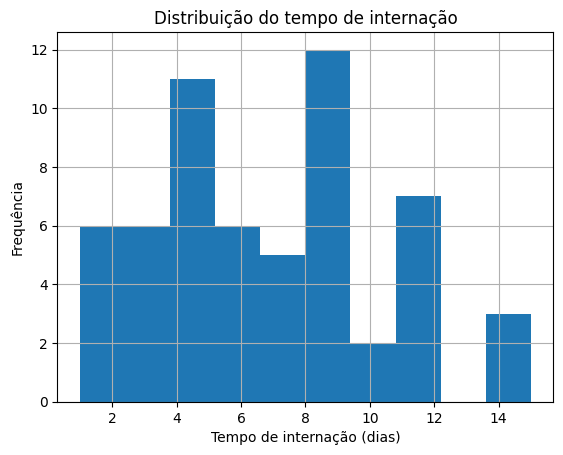

In [26]:
df["tempo_internacao_dias"].hist(bins=10)
plt.xlabel("Tempo de internação (dias)")
plt.ylabel("Frequência")
plt.title("Distribuição do tempo de internação")
plt.show()

1. Os valores se concentram em uma região?
2. Há uma cauda para valores maiores?
3. Média e mediana combinam com o formato?


Média e mediana descrevem o centro; desvio-padrão e IQR, a dispersão, cada par por perspectivas diferentes.

### Exercício — Primeiro perfil do caso-guia

Responda às perguntas com código e, ao final, escreva um parágrafo descritivo **sem linguagem causal**.

1. Quantas observações existem na base?
2. Como os pacientes se distribuem entre os serviços?
3. Qual é a frequência de readmissão em 30 dias?
4. Qual é a idade típica e quanta variabilidade existe?
5. Média e mediana do tempo de internação são próximas?
6. Alguma variável tem muitas ausências?

In [27]:
# 1. Quantas observações existem na base?

In [28]:
# 2. Como os pacientes se distribuem entre os serviços?

In [29]:
# 3. Qual é a frequência de readmissão em 30 dias?

In [30]:
# 4. Qual é a idade típica e quanta variabilidade existe?

In [31]:
# 5. Média e mediana do tempo de internação são próximas?

In [32]:
# 6. Alguma variável tem muitas ausências?

---
## Erros comuns

1. Calcular a média de uma categoria codificada como número
2. Usar `mean()` sem checar quantos valores são válidos
3. Tratar o maior valor como erro sem contexto
4. Confundir desvio-padrão com erro da média
5. Esquecer que `value_counts()` exclui ausências
6. Comparar percentuais sem olhar os denominadores
7. Ler diferença entre serviços como efeito
8. Parar no `describe()` sem interpretar

## Próxima aula

**Aula 8: padrões, outliers e hipóteses.** Descrever cada variável separadamente ainda não responde se existem padrões entre essas características.